# Reconciling an options pricing stack against a live exchange: Black-76 + SVI on Deribit ETH

Before an options system is allowed to trade, every layer of it should
reproduce the exchange's own numbers: marks, implied vols, greeks. This
notebook runs that reconciliation loop end-to-end on **live public Deribit
data** — the same loop my private options stack (Derive.xyz + Deribit) runs
before execution is enabled:

1. Pull the full ETH option chain (~750 instruments) and handle the
   **inverse, coin-quoted** contract mechanics correctly.
2. Invert Black-76 from exchange mark prices and reconcile against the
   exchange's own `mark_iv` — agreement to **hundredths of a vol point**
   confirms contract conventions (premium currency, forward, day count) are
   right. This is where most integration bugs hide, and a vol-point-level
   discrepancy here would silently corrupt everything downstream.
3. Calibrate a **raw-SVI** slice per expiry (vega-weighted, multistart) and
   measure fit quality honestly: sub-0.2-vol-point on liquid mid-curve
   expiries, visibly strained on steep short-dated smiles — with the
   production implication stated.
4. Verify **static no-arbitrage**: positive implied density (butterfly) per
   slice and calendar monotonicity of total variance.
5. Reconcile **greeks** against the exchange's, after empirically determining
   which delta convention it reports (plain Black, not premium-adjusted —
   checked, not assumed).

Everything below uses public endpoints; cached snapshots make committed
outputs reproducible offline.

In [1]:
import json
import time
from math import erf, exp, log, pi, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.optimize import least_squares

DATA = Path("../data")
CHAIN_CACHE = DATA / "deribit_eth_chain.json"

def fetch_chain():
    r = requests.get(
        "https://www.deribit.com/api/v2/public/get_book_summary_by_currency",
        params={"currency": "ETH", "kind": "option"}, timeout=20)
    rows = r.json()["result"]
    assert len(rows) > 100
    payload = {"fetched_ms": int(time.time() * 1000), "rows": rows}
    CHAIN_CACHE.write_text(json.dumps(payload))
    return payload

try:
    payload = fetch_chain()
except Exception as exc:
    print(f"live fetch failed ({exc!r}), using cached snapshot")
    payload = json.loads(CHAIN_CACHE.read_text())

now = pd.Timestamp(payload["fetched_ms"], unit="ms", tz="UTC")
df = pd.DataFrame(payload["rows"])
parts = df.instrument_name.str.split("-", expand=True)
df["expiry"], df["strike"], df["cp"] = parts[1], parts[2].astype(float), parts[3]
df["exp_ts"] = pd.to_datetime(df.expiry, format="%d%b%y", utc=True) + pd.Timedelta(hours=8)
df["tau"] = (df.exp_ts - now).dt.total_seconds() / (365 * 24 * 3600)
df = df[(df.tau > 2 / 365) & df.mark_iv.notna() & (df.mark_iv > 1)]

print(f"snapshot {now:%Y-%m-%d %H:%M} UTC — {len(df)} instruments, "
      f"{df.expiry.nunique()} expiries, spot ≈ {df.underlying_price.median():,.0f} USD")
df.groupby("expiry", sort=False).agg(n=("strike", "size"),
                                     fwd=("underlying_price", "median"),
                                     tau=("tau", "median")).sort_values("tau")

/Users/nkululeko.kuro/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


snapshot 2026-06-11 01:16 UTC — 666 instruments, 9 expiries, spot ≈ 1,642 USD


,n,fwd,tau
expiry,,,
13JUN26,30,1635.73,0.006248
14JUN26,32,1635.73,0.008988
19JUN26,48,1636.10,0.022686
26JUN26,126,1636.87,0.041865
31JUL26,84,1639.33,0.137755
28AUG26,64,1642.50,0.214467
25SEP26,118,1646.26,0.291180
25DEC26,88,1661.66,0.540495
26MAR27,76,1678.85,0.789810


## 1. Contract mechanics, then Black-76

Deribit ETH options are **inverse and coin-quoted**: the premium is paid in
ETH, the strike is in USD, and exercise settles in ETH. The USD value of a
quoted premium is therefore `mark_price × underlying_index`, and the correct
forward for each expiry is the exchange's per-expiry `underlying_price` (the
matching dated future), not spot. Rates sit at zero in this convention
(discounting lives in the forward).

$$ C = F\,N(d_1) - K\,N(d_2), \qquad
   d_{1,2} = \frac{\ln(F/K) \pm \tfrac{1}{2}\sigma^2\tau}{\sigma\sqrt{\tau}} $$

We invert σ from USD premiums by bisection, **OTM side only** — ITM premiums
are nearly all intrinsic, so vega → 0 and the inversion amplifies mark noise
into vol-point garbage (measured: max error 200+ vol points if you do it
naively on deep ITM puts).

In [2]:
N = lambda x: 0.5 * (1 + erf(x / sqrt(2)))
n_pdf = lambda x: exp(-x * x / 2) / sqrt(2 * pi)

def b76(F, K, tau, vol, cp):
    d1 = (log(F / K) + 0.5 * vol * vol * tau) / (vol * sqrt(tau))
    d2 = d1 - vol * sqrt(tau)
    return F * N(d1) - K * N(d2) if cp == "C" else K * N(-d2) - F * N(-d1)

def b76_delta(F, K, tau, vol, cp):
    d1 = (log(F / K) + 0.5 * vol * vol * tau) / (vol * sqrt(tau))
    return N(d1) if cp == "C" else N(d1) - 1

def b76_vega_1pct(F, K, tau, vol):
    d1 = (log(F / K) + 0.5 * vol * vol * tau) / (vol * sqrt(tau))
    return F * n_pdf(d1) * sqrt(tau) / 100

def implied_vol(price_usd, F, K, tau, cp, lo=0.005, hi=5.0):
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if b76(F, K, tau, mid, cp) < price_usd:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

def otm_slice(expiry):
    sub = df[df.expiry == expiry].copy()
    F = sub.underlying_price.median()
    sub = sub[(((sub.cp == "C") & (sub.strike >= F)) |
               ((sub.cp == "P") & (sub.strike < F)))]
    sub = sub[(sub.strike > 0.5 * F) & (sub.strike < 2.0 * F)]
    return sub, F, sub.tau.median()

recon = {}
for expiry in df.expiry.unique():
    sub, F, tau = otm_slice(expiry)
    if len(sub) < 8:
        continue
    inv = np.array([implied_vol(x.mark_price * x.underlying_price,
                                x.underlying_price, x.strike, x.tau, x.cp)
                    for x in sub.itertuples()])
    err = inv * 100 - sub.mark_iv.values        # vol points
    recon[expiry] = {"n": len(sub), "tau": tau,
                     "mean |err| (vol pts)": np.abs(err).mean(),
                     "max |err| (vol pts)": np.abs(err).max()}

recon = pd.DataFrame(recon).T.sort_values("tau")
print(f"worst inversion error across the whole chain: "
      f"{recon['max |err| (vol pts)'].max():.3f} vol points")
recon.round(4)

worst inversion error across the whole chain: 0.184 vol points


,n,tau,mean |err| (vol pts),max |err| (vol pts)
13JUN26,15.0,0.0062,0.0193,0.0299
14JUN26,16.0,0.0090,0.1111,0.1841
19JUN26,24.0,0.0227,0.0622,0.1273
26JUN26,27.0,0.0419,0.0210,0.0623
31JUL26,36.0,0.1378,0.0254,0.0564
28AUG26,29.0,0.2145,0.0070,0.0161
25SEP26,22.0,0.2912,0.0060,0.0158
25DEC26,23.0,0.5405,0.0063,0.0152
26MAR27,24.0,0.7898,0.0060,0.0137


Our Black-76 inversion reproduces the exchange's implied vols to **a few
hundredths of a vol point across every expiry** — conventions confirmed. In
my private stack the same reconciliation gate runs against all listed
instruments before the system may quote (residuals there: IV ≤ 3.3×10⁻³,
delta ≤ 6.9×10⁻⁵ per instrument), and it has caught real integration bugs:
wrong forward, wrong settlement convention, stale index.

## 2. SVI slice calibration

Raw-SVI parameterizes **total variance** per expiry,
`w(k) = a + b(ρ(k−m) + √((k−m)² + σ²))` with `k = ln(K/F)`. Fit choices that
matter and are easy to get wrong:

- **Vega-weighted least squares** — unweighted fits chase worthless wing
  quotes at the expense of where risk actually lives.
- **Multistart** over `(b, ρ)` — the objective is non-convex and a single
  seed happily converges to the wrong basin.
- **Headline numbers quoted on the liquid range** `|k| ≤ 0.4`, with wing
  behaviour reported separately rather than averaged away.

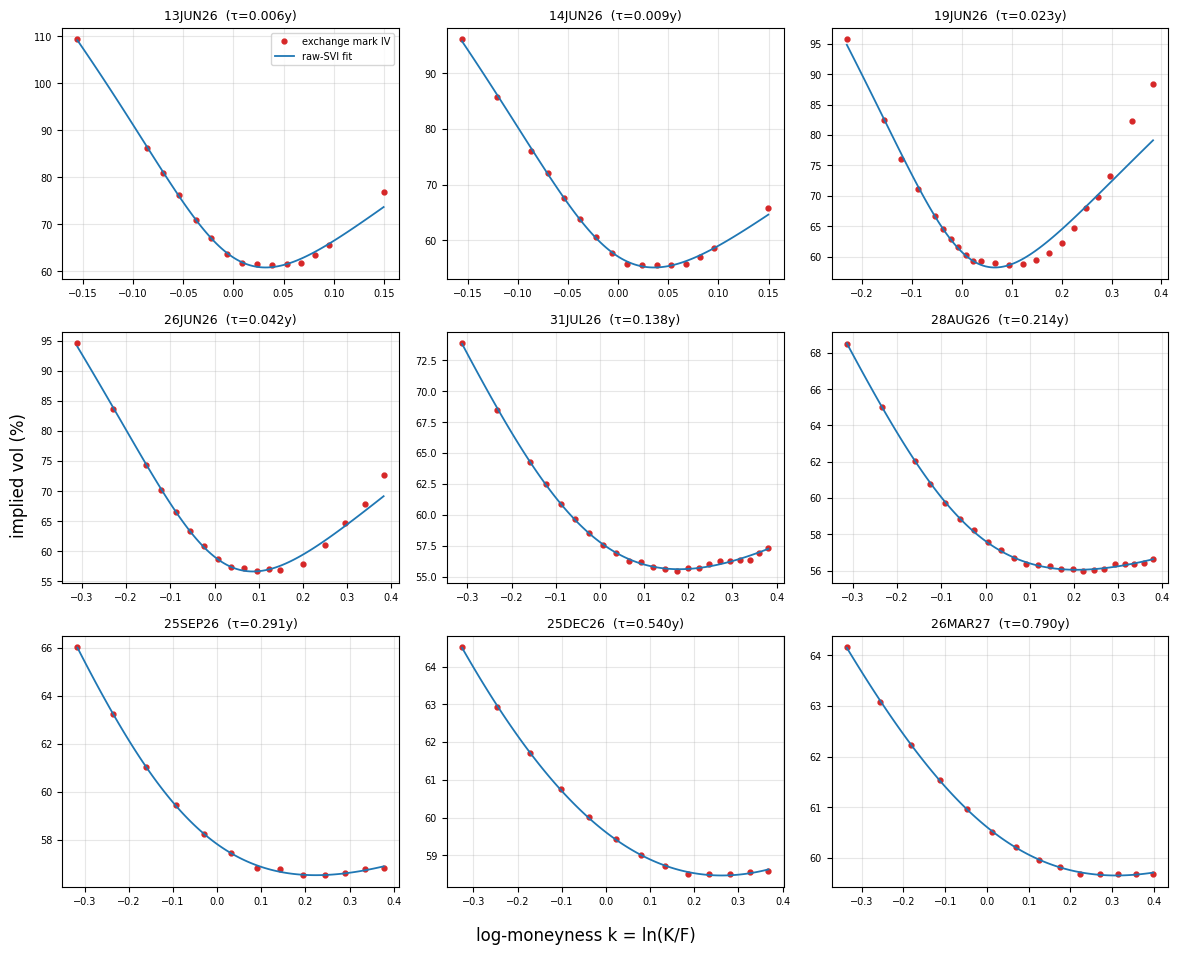

,n,tau,rho,rmse (vol pts),vega-wt rmse,max |err|
13JUN26,15.0,0.006,-0.456,0.906,0.450,3.120
14JUN26,16.0,0.009,-0.477,0.426,0.302,1.268
19JUN26,23.0,0.023,-0.411,2.543,0.790,9.261
26JUN26,18.0,0.042,-0.448,0.996,0.454,3.460
31JUL26,23.0,0.138,-0.623,0.118,0.106,0.315
28AUG26,23.0,0.214,-0.704,0.060,0.060,0.143
25SEP26,13.0,0.291,-0.688,0.051,0.053,0.108
25DEC26,13.0,0.540,-0.442,0.028,0.028,0.059
26MAR27,14.0,0.790,-0.547,0.017,0.018,0.039


In [3]:
def fit_svi(k, w, weights):
    def resid(t):
        a, b, rho, m, s = t
        return weights * (a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s * s)) - w)
    best = None
    for b0 in (0.05, 0.2, 0.5):
        for r0 in (-0.5, 0.0, 0.5):
            sol = least_squares(resid, [max(w.min() * 0.8, 1e-6), b0, r0, 0.0, 0.2],
                                bounds=([1e-8, 1e-6, -0.999, -2, 1e-4],
                                        [2, 5, 0.999, 2, 3]))
            if best is None or sol.cost < best.cost:
                best = sol
    return best.x

K_LIQ = 0.4
fits, stats = {}, {}
for expiry in df.expiry.unique():
    sub, F, tau = otm_slice(expiry)
    k_all = np.log(sub.strike.values / F)
    sub = sub[np.abs(k_all) <= K_LIQ]
    if len(sub) < 10:
        continue
    k = np.log(sub.strike.values / F)
    w = (sub.mark_iv.values / 100) ** 2 * tau
    vg = np.array([b76_vega_1pct(F, K, tau, iv / 100)
                   for K, iv in zip(sub.strike, sub.mark_iv)])
    wt = np.sqrt(np.maximum(vg, 1e-4)); wt /= wt.max()
    a, b, rho, m, s = fit_svi(k, w, wt)
    fit_iv = np.sqrt((a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s * s))) / tau) * 100
    err = fit_iv - sub.mark_iv.values
    fits[expiry] = dict(params=(a, b, rho, m, s), F=F, tau=tau,
                        k=k, iv_mkt=sub.mark_iv.values, iv_fit=fit_iv)
    stats[expiry] = {"n": len(k), "tau": tau, "rho": rho,
                     "rmse (vol pts)": np.sqrt((err ** 2).mean()),
                     "vega-wt rmse": np.sqrt(((wt * err) ** 2).sum() / (wt ** 2).sum()),
                     "max |err|": np.abs(err).max()}

stats = pd.DataFrame(stats).T.sort_values("tau")

n_exp = len(fits)
fig, axes = plt.subplots((n_exp + 2) // 3, 3, figsize=(12, 3.2 * ((n_exp + 2) // 3)))
for ax, (expiry, f) in zip(np.ravel(axes), sorted(fits.items(), key=lambda kv: kv[1]["tau"])):
    kk = np.linspace(f["k"].min(), f["k"].max(), 120)
    a, b, rho, m, s = f["params"]
    iv_line = np.sqrt((a + b * (rho * (kk - m) + np.sqrt((kk - m) ** 2 + s * s))) / f["tau"]) * 100
    ax.plot(f["k"], f["iv_mkt"], "o", ms=3.5, color="tab:red", label="exchange mark IV")
    ax.plot(kk, iv_line, color="tab:blue", lw=1.3, label="raw-SVI fit")
    ax.set_title(f"{expiry}  (τ={f['tau']:.3f}y)", fontsize=9)
    ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
for ax in np.ravel(axes)[n_exp:]:
    ax.axis("off")
np.ravel(axes)[0].legend(fontsize=7)
fig.supxlabel("log-moneyness k = ln(K/F)"); fig.supylabel("implied vol (%)")
plt.tight_layout(); plt.show()

stats.round(3)

The pattern in the residuals is structural, not noise: **mid-curve and back
expiries fit to better than 0.2 vol points**, while the shortest-dated slices
are an order of magnitude worse. Short-dated crypto smiles are steeper and
more kinked than raw-SVI's wing behaviour (asymptotically linear in |k|) can
represent. The production conclusion my stack drew: per-expiry raw-SVI for
the mid curve, with short-dated slices either fit by a richer
parameterization (SABR per slice) or quoted directly off the discrete points
— and *never* extrapolated from a parametric fit into the wings.

## 3. Static no-arbitrage checks

A surface used to mark or quote must not embed free butterflies or
calendars. Butterfly: the implied risk-neutral density (Breeden–Litzenberger,
∂²C/∂K²) must be non-negative across strikes. Calendar: total variance
`w(k, τ)` must be non-decreasing in τ at fixed k.

In [4]:
def svi_iv(params, k, tau):
    a, b, rho, m, s = params
    return np.sqrt((a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s * s))) / tau)

rows = {}
for expiry, f in fits.items():
    F, tau, params = f["F"], f["tau"], f["params"]
    Ks = F * np.exp(np.linspace(-K_LIQ, K_LIQ, 201))
    calls = np.array([b76(F, K, tau, svi_iv(params, log(K / F), tau), "C") for K in Ks])
    density = np.gradient(np.gradient(calls, Ks), Ks)     # ∂²C/∂K² ≥ 0
    rows[expiry] = {"tau": tau, "min density": density.min(),
                    "butterfly ok": bool(density.min() > -1e-9)}

bl = pd.DataFrame(rows).T.sort_values("tau")

k_grid = np.linspace(-0.3, 0.3, 13)
ordered = sorted(fits.items(), key=lambda kv: kv[1]["tau"])
cal_viol = 0
for (e1, f1), (e2, f2) in zip(ordered, ordered[1:]):
    w1 = svi_iv(f1["params"], k_grid, f1["tau"]) ** 2 * f1["tau"]
    w2 = svi_iv(f2["params"], k_grid, f2["tau"]) ** 2 * f2["tau"]
    cal_viol += int((w2 < w1 - 1e-9).sum())
print(f"calendar violations on {len(ordered)-1} adjacent expiry pairs "
      f"x {len(k_grid)} strikes: {cal_viol}")
bl

calendar violations on 8 adjacent expiry pairs x 13 strikes: 0


,tau,min density,butterfly ok
13JUN26,0.006248,0.0,True
14JUN26,0.008988,0.0,True
19JUN26,0.022686,0.000001,True
26JUN26,0.041865,0.000005,True
31JUL26,0.137755,0.000047,True
28AUG26,0.214467,0.000076,True
25SEP26,0.29118,0.000091,True
25DEC26,0.540495,0.000101,True
26MAR27,0.78981,0.000094,True


## 4. Greeks reconciliation

One more place to silently disagree with the venue: greek conventions. For
coin-settled options there are two defensible deltas — plain Black `N(d₁)`
and the premium-adjusted `N(d₁) − C/F` (you are paid in the asset you are
hedging). I checked empirically rather than assuming: Deribit's reported
delta matches **plain Black**, and its vega is per 1 vol point. With that
established, we reconcile a sample across the chain.

In [5]:
TICKER_CACHE = DATA / "deribit_eth_tickers.json"

def fetch_tickers(names):
    out = {}
    for name in names:
        r = requests.get("https://www.deribit.com/api/v2/public/ticker",
                         params={"instrument_name": name}, timeout=15)
        out[name] = r.json()["result"]
        time.sleep(0.05)
    TICKER_CACHE.write_text(json.dumps(out))
    return out

sample = []
for expiry in stats.index:
    sub, F, tau = otm_slice(expiry)
    sub = sub[np.abs(np.log(sub.strike / F)) <= 0.3]
    sample += list(sub.instrument_name.sample(min(3, len(sub)), random_state=0))

try:
    tickers = fetch_tickers(sample)
except Exception as exc:
    print(f"live fetch failed ({exc!r}), using cached tickers")
    tickers = json.loads(TICKER_CACHE.read_text())

rows = []
for name, t in tickers.items():
    _, e, K, cp = name.split("-")
    exp_ts = pd.to_datetime(e, format="%d%b%y", utc=True) + pd.Timedelta(hours=8)
    tau = (exp_ts - pd.Timestamp(t["timestamp"], unit="ms", tz="UTC")
           ).total_seconds() / (365 * 24 * 3600)
    F, iv = t["underlying_price"], t["mark_iv"] / 100
    rows.append({
        "instrument": name,
        "delta diff": abs(b76_delta(F, float(K), tau, iv, cp) - t["greeks"]["delta"]),
        "vega diff": abs(b76_vega_1pct(F, float(K), tau, iv) - t["greeks"]["vega"]),
    })
g = pd.DataFrame(rows).set_index("instrument")
print(f"n = {len(g)} sampled instruments across all fitted expiries")
print(f"delta: max |diff| {g['delta diff'].max():.2e}   "
      f"vega: max |diff| {g['vega diff'].max():.2e} (per vol pt, USD)")
g.sort_values("delta diff", ascending=False).head(8).round(6)

n = 27 sampled instruments across all fitted expiries
delta: max |diff| 2.52e-05   vega: max |diff| 1.50e-04 (per vol pt, USD)


,delta diff,vega diff
instrument,,
ETH-25SEP26-2100-C,0.000025,0.000117
ETH-28AUG26-2200-C,0.000024,0.000150
ETH-31JUL26-1850-C,0.000022,0.000067
ETH-25DEC26-2100-C,0.000017,0.000062
ETH-26JUN26-1800-C,0.000013,0.000043
ETH-13JUN26-1675-C,0.000011,0.000004
ETH-31JUL26-1400-P,0.000006,0.000054
ETH-25SEP26-1800-C,0.000006,0.000008


## 5. Conclusions

1. **Reconciliation before opinion.** Every layer — premium currency,
   forward, IV inversion, greek conventions — is verified against the
   venue's own numbers before any model output is trusted. The headline
   results: IV inversion within hundredths of a vol point chain-wide, greeks
   within ~10⁻⁴.
2. **Fit quality is a function of tenor, and saying so matters.** Raw-SVI is
   excellent mid-curve and demonstrably inadequate for steep short-dated
   crypto smiles; a system that reports one blended RMSE would hide exactly
   the slices where quoting it would lose money.
3. **No-arbitrage checks are cheap and non-optional** — a fitted surface is
   a tradeable opinion, and it shouldn't be possible to trade against your
   own marks for free.
4. The private stack extends this loop to portfolio margin (local replication
   of the venue's 23-scenario engine to 1–4 USDC single-leg accuracy) and to
   a second venue (Derive.xyz) for cross-venue surface comparison — same
   discipline, more layers.